<a href="https://colab.research.google.com/github/vanefdzloera/VERANO-IA-2026/blob/main/PIA/PIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Artificial Intelligence final project

*   Alexa Gutiérrez Salgado 2114666
*   Claudia Vanessa Fernandez Loera 2094781

Hora clase: V4-V6


## **Libraries**

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import os
import kagglehub
from sklearn.model_selection import train_test_split

## **Preprocessing**

In [2]:
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


In [3]:
print("Path to dataset files:", path)


Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [4]:
metadata = pd.read_csv(path + '/HAM10000_metadata.csv')

In [5]:
clases = metadata['dx'].unique()
diccionario = {clase: i for i, clase in enumerate(clases)}
print(clases)

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']


In [6]:
clases = list(clases)
imagenes = []
etiquetas = []

In [7]:
for _, row in metadata.iterrows():
    nombre = row['image_id'] + '.jpg'
    ruta1 = path + '/HAM10000_images_part_1/' + nombre
    ruta2 = path + '/HAM10000_images_part_2/' + nombre

    img = cv2.imread(ruta1) if os.path.exists(ruta1) else cv2.imread(ruta2)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resize_final = cv2.resize(img_rgb, (128, 128))
    imagenes.append(img_resize_final)
    etiquetas.append(diccionario[row['dx']])

In [8]:
X = np.array(imagenes)
y = np.array(etiquetas)

In [9]:
train_images, test_images, train_labels, test_labels = train_test_split(X, y, test_size=0.20, random_state=42)

In [10]:
print(train_images.shape)
print(len(train_labels))
print(train_labels)

(8012, 128, 128, 3)
8012
[1 1 1 ... 1 0 1]


In [11]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [12]:
file = path + '/HAM10000_images_part_1/ISIC_0027419.jpg'
test_image = cv2.imread(file)
test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)

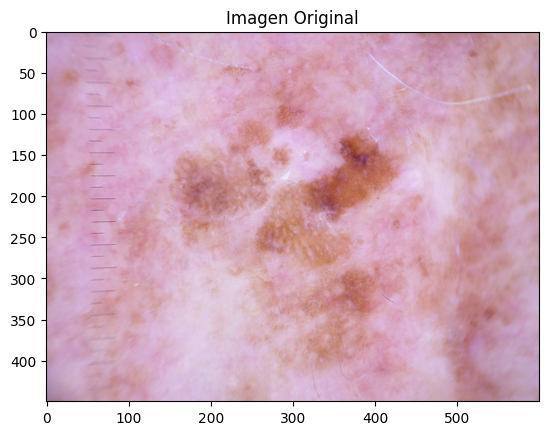

In [13]:
plt.imshow(test_image)
plt.title("Imagen Original")
plt.show()

In [14]:
img_resized = cv2.resize(test_image, (128, 128))

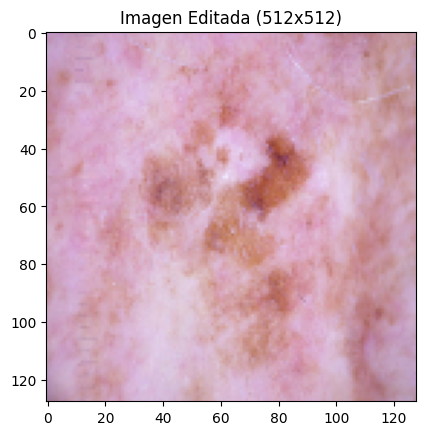

In [15]:
os.makedirs('/content/Pruebas_PIA', exist_ok=True)
plt.imshow(img_resized)
plt.title("Imagen Editada (512x512)")
plt.savefig("/content/Pruebas_PIA/abc.png")
plt.show()

## **CNN Training**

In [17]:
model = keras.models.Sequential()
model.add(keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))
model.add(keras.layers.Conv2D(64, (3, 3), activation='relu'))
model.add(keras.layers.MaxPooling2D((2, 2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(7, activation='softmax'))

In [20]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [21]:
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 251s 990ms/step - accuracy: 0.6717 - loss: 0.9962 - val_accuracy: 0.6885 - val_loss: 0.9348
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 249s 991ms/step - accuracy: 0.6840 - loss: 0.8925 - val_accuracy: 0.6760 - val_loss: 0.9712
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.6960 - loss: 0.8452 - val_accuracy: 0.6940 - val_loss: 0.8669
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 253s 1s/step - accuracy: 0.7073 - loss: 0.8072 - val_accuracy: 0.6975 - val_loss: 0.8445
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 239s 952ms/step - accuracy: 0.7243 - loss: 0.7507 - val_accuracy: 0.7114 - val_loss: 0.8067
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 264s 957ms/step - accuracy: 0.7355 - loss: 0.7149 - val_accuracy: 0.7199 - val_loss: 0.7707
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.7471 - loss: 0.6851 - val_accuracy: 0.7304 - val_loss: 0.7454
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.7580 - loss: 0.655

## **10 Predictions**

In [22]:
predictions = model.predict(test_images)

63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 264ms/step


In [26]:
print("\n--- Resultados de 10 Predicciones ---")
for i in range(10):
    indice_predicho = np.argmax(predictions[i])
    indice_real = test_labels[i]

    x = clases[indice_predicho]
    y = clases[indice_real]


--- Resultados de 10 Predicciones ---


In [27]:
print("La red dice que la imagen " + str(i) + " es clase " + x + " y la clase verdadera es: " + y)

La red dice que la imagen 9 es clase nv y la clase verdadera es: nv


## **Plot of training accuracy vs validation accuracy**

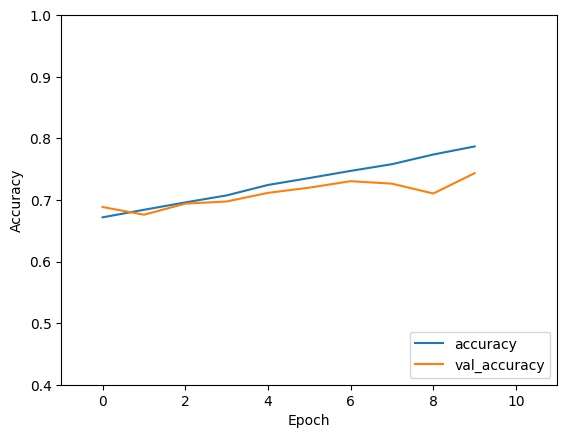

In [28]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.4, 1])
plt.xlim([-1, 11])
plt.legend(loc='lower right')
plt.show()

In [29]:
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

63/63 - 17s - 270ms/step - accuracy: 0.7434 - loss: 0.7262
